### 데이터 불러오기

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 데이터 불러오기
df = pd.read_csv('data/steam-200k.csv',
                 header=None,
                 names=['user_id', 'game_title', 'behavior', 'hours', 'empty'])
df.head(10)

,user_id,game_title,behavior,hours,empty
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
5,151603712,Spore,play,14.9,0
6,151603712,Fallout New Vegas,purchase,1.0,0
7,151603712,Fallout New Vegas,play,12.1,0
8,151603712,Left 4 Dead 2,purchase,1.0,0
9,151603712,Left 4 Dead 2,play,8.9,0


### STEP A. 기본 현황 파악

In [10]:
print("전체 행수:", len(df))
print("유니크 유저 수:", df['user_id'].nunique())
print("유니크 게임 수:", df['game_title'].nunique())
print("\nbehavior 종류:")
print(df['behavior'].value_counts())

전체 행수: 200000
유니크 유저 수: 12393
유니크 게임 수: 5155

behavior 종류:
behavior
purchase    129511
play         70489
Name: count, dtype: int64


### STEP B. 구매 -> 플레이 전환율 (퍼널)

In [13]:
# 구매한 유저
purchased = df[df['behavior'] == 'purchase']['user_id'].nunique()

# 실제 플레이한 유저
played = df[df['behavior'] == 'play']['user_id'].nunique()

# 전환율
conversion = round(played / purchased * 100, 1)

print(f"구매 유저: {purchased:,}명")
print(f"실제 플레이 유저: {played:,}명")
print(f"구매->플레이 전환율: {conversion}%")

구매 유저: 12,393명
실제 플레이 유저: 11,350명
구매->플레이 전환율: 91.6%


### STEP C. 게임별 평균 플레이 시간 Top 10

In [28]:
top_games = (
    df[df['behavior'] == 'play']
    .groupby('game_title')['hours']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'hours': 'avg_hours'})
)

top_games['avg_hours'] = top_games['avg_hours'].round(1)
top_games

,game_title,avg_hours
0,Eastside Hockey Manager,1295.0
1,Baldur's Gate II Enhanced Edition,475.3
2,FIFA Manager 09,411.0
3,Perpetuum,401.0
4,Football Manager 2014,392.0
5,Football Manager 2012,390.5
6,Football Manager 2010,375.0
7,Football Manager 2011,365.7
8,Freaking Meatbags,331.0
9,Out of the Park Baseball 16,330.4


### STEP D. 플레이 시간 구간별 유저 분포 (퍼널)


In [38]:
# play 데이터만 추출
play_df = df[df['behavior'] == 'play'].copy()

# 유저별 총 플레이 시간 합산
user_hours = play_df.groupby('user_id')['hours'].sum().reset_index()
user_hours.columns = ['user_id', 'total_hours']

# 구간 나누기
def classify_user(hours):
    if hours < 1:
        return '0. 1시간 미만'
    elif hours < 10:
        return '1. 1~10시간'
    elif hours < 50:
        return '2. 10~50시간'
    elif hours < 200:
        return '3. 50~200시간'
    else:
        return '4. 200시간 이상'
    
user_hours['segment'] = user_hours['total_hours'].apply(classify_user)

# 집계
funnel = user_hours['segment'].value_counts().sort_index().reset_index()
funnel.columns = ['segment', 'user_count']
funnel['pct'] = (funnel['user_count']/len(user_hours) * 100).round(1)

print(funnel)

       segment  user_count   pct
0    0. 1시간 미만        1693  14.9
1    1. 1~10시간        3068  27.0
2   2. 10~50시간        2130  18.8
3  3. 50~200시간        1624  14.3
4  4. 200시간 이상        2835  25.0


### STEP E. 시각화


/var/folders/t1/wv2fbxgd5tb7wnxyqnsmp0wr0000gn/T/ipykernel_23061/3540148800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=funnel, x='segment', y='user_count', palette='Blues_d')


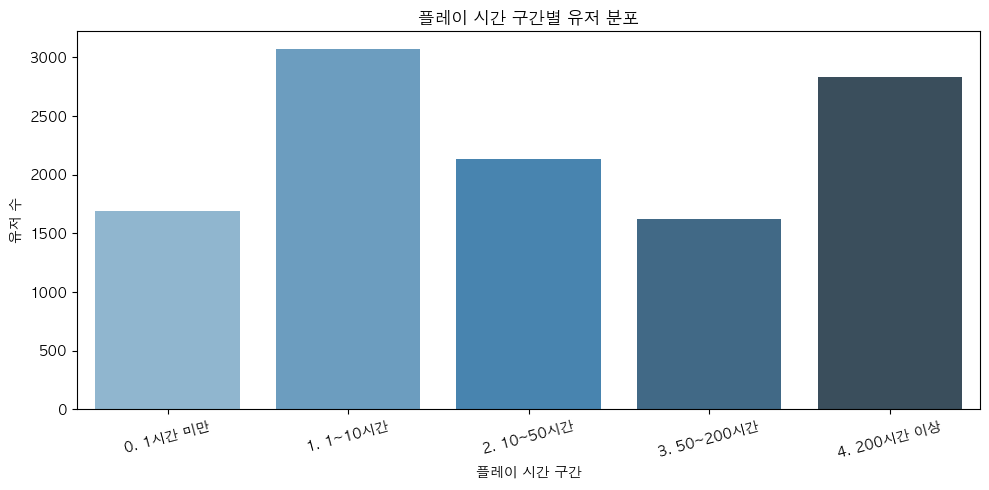

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(data=funnel, x='segment', y='user_count', palette='Blues_d')
plt.title('플레이 시간 구간별 유저 분포')
plt.xlabel('플레이 시간 구간')
plt.ylabel('유저 수')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('steam_funnel.png')
plt.show()